In [5]:
import os, gc, joblib
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd

import cupy as cp
import xgboost as xgb

import onnxmltools
from onnxmltools.convert.common.data_types import FloatTensorType

BUILD95 = True
BUILD96 = True

In [6]:
train_str_transaction_identity = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain','M1', 'M2', 'M3', 'M4','M5',
            'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 
            'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

test_str_identity = ['id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 
            'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38','DeviceType', 'DeviceInfo']

cat_cols= train_str_transaction_identity + test_str_identity

In [7]:
num_cols_transaction=['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']

num_cols_identity=[]

num_cols= num_cols_identity + num_cols_transaction

In [8]:
train_transaction_cols_excl_v=['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']


## Feature Selection Strategy

To improve interpretability and establish a robust baseline, we exclude:

1. The target variable: `isFraud`
2. Anonymous PCA-transformed features: `V1`–`V339`
3. Selected identity attributes with high missingness or limited interpretability.

This allows the model to first learn from transaction-level features before introducing high-dimensional latent representations.

> **Note:** Anonymous `V` features are latent variables generated by the competition organizers and are not directly interpretable. They may be incorporated in later experiments after establishing a strong baseline using interpretable features.

## V Cols loading

In [9]:
# V COLUMNS TO LOAD DECIDED BY CORRELATION EDA
# https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id
v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]

#v += [96, 98, 99, 104] #relates to groups, no NAN 
v += [107, 108, 111, 115, 117, 120, 121, 123] # maybe group, no NAN
v += [124, 127, 129, 130, 136] # relates to groups, no NAN

# LOTS OF NAN BELOW
v += [138, 139, 142, 147, 156, 162] #b1
v += [165, 160, 166] #b1
v += [178, 176, 173, 182] #b2
v += [187, 203, 205, 207, 215] #b2
v += [169, 171, 175, 180, 185, 188, 198, 210, 209] #b2
v += [218, 223, 224, 226, 228, 229, 235] #b3
v += [240, 258, 257, 253, 252, 260, 261] #b3
v += [264, 266, 267, 274, 277] #b3
v += [220, 221, 234, 238, 250, 271] #b3

v += [294, 284, 285, 286, 291, 297] # relates to grous, no NAN
v += [303, 305, 307, 309, 310, 320] # relates to groups, no NAN
v += [281, 283, 289, 296, 301, 314] # relates to groups, no NAN
#v += [332, 325, 335, 338] # b4 lots NAN

"""premos : the above #v += [332, 325, 335, 338] # b4 lots NAN, is ommited because they have the mose nan values and hence would be of no use"""

""" still gpt says : Sometimes a column with 95% NaNs can still be extremely predictive, so practitioners usually validate this empirically."""
train_transaction_v_cols_only = ['V'+str(x) for x in v]

cols =train_transaction_v_cols_only+train_transaction_cols_excl_v

cols=num_cols #+ cat_cols

The below code aims to create a datatypes of each column dictionary

In [10]:
dtypes={}

for c in cols+["id_0"+str(i) for i in range(1,10)]+["id-0"+str(j) for j in range(1,10)] \
    +["id_"+str(i) for i in range(10,34)]+["id-"+str(i) for j in range(10,34)]:
    dtypes[c]="float32"

for c in cat_cols:
    dtypes[c]="category"

In [11]:
%%time

X_train=pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv",
                    dtype=dtypes,
                    usecols=cols+["isFraud"],
                    index_col='TransactionID'
                   )

X_train_identity=pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv",
                      dtype=dtypes,
                      index_col='TransactionID'
                      )

X_train=X_train.merge(X_train_identity,how="left",left_index=True,right_index=True)



X_test=pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv",
                  dtype=dtypes,
                  usecols=cols,
                  index_col='TransactionID'
                  )

X_test_identity=pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv",
                           dtype=dtypes,
                           index_col='TransactionID'
                           )

col_map={i:j for i,j in zip(X_test_identity.columns,X_train_identity.columns)}

X_test_identity.rename(columns=col_map, inplace=True)

X_test=X_test.merge(X_test_identity,how="left",left_index=True,right_index=True)

Y_train=X_train["isFraud"].copy()

del X_train["isFraud"], X_train_identity, X_test_identity
gc.collect()

print("X_train shape",X_train.shape)
print("\n")
print("X_test shape",X_test.shape)




X_train shape (590540, 93)


X_test shape (506691, 93)
CPU times: user 15.7 s, sys: 723 ms, total: 16.4 s
Wall time: 24.9 s


# Normalize D Columns
The D Columns are "time deltas" from some point in the past. We will transform the D Columns into their point in the past. This will stop the D columns from increasing with time. The formula is `D15n = Transaction_Day - D15` and `Transaction_Day = TransactionDT/(24*60*60)`. Afterward we multiple this number by negative one.

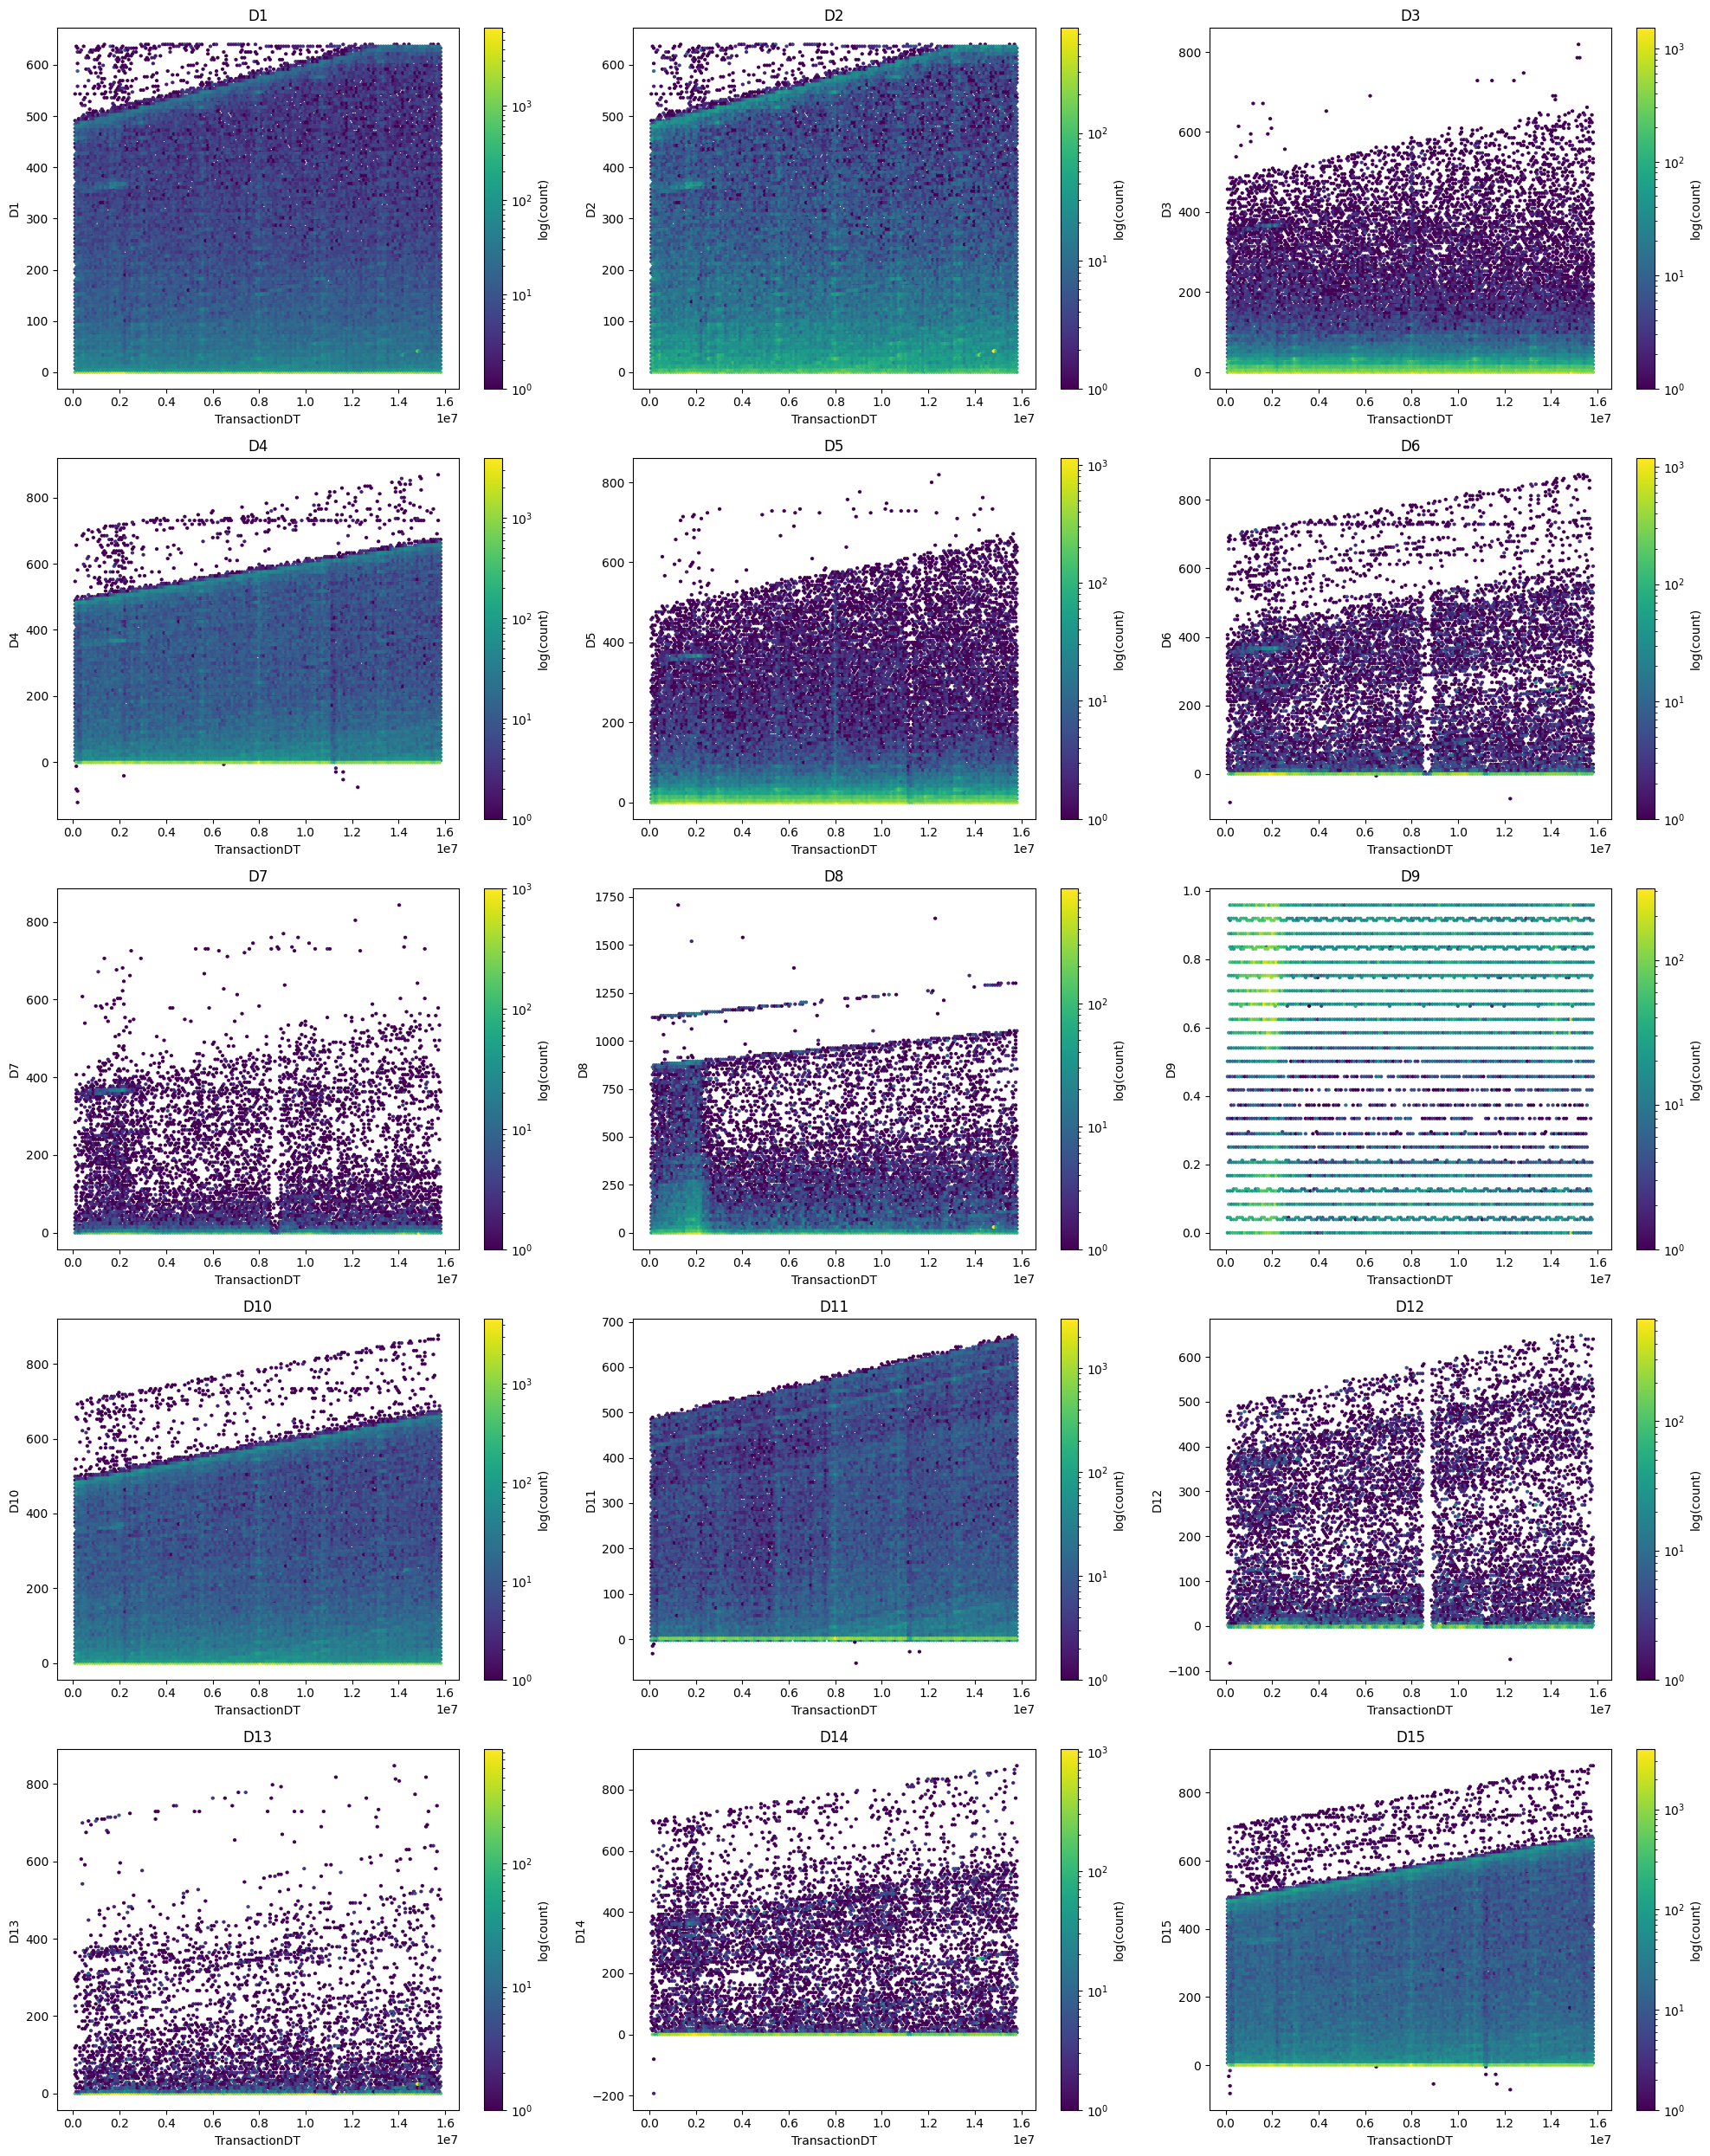

In [12]:
fig, axes = plt.subplots(5, 3, figsize=(20, 25))
axes = axes.flatten()

for i in range(1, 16):
    col = f'D{i}'
    subset = X_train[X_train[col].notna()]
    
    hb = axes[i-1].hexbin(
        subset['TransactionDT'],
        subset[col],
        gridsize=150,
        bins='log',
        cmap='viridis',
        mincnt=1
    )

    axes[i-1].set_title(col)
    axes[i-1].set_xlabel('TransactionDT')
    axes[i-1].set_ylabel(col)

    # Individual colorbar for each subplot
    fig.colorbar(hb, ax=axes[i-1], label='log(count)')

plt.tight_layout()
plt.show()


## Transform

The D values which are increasing as TransactionDT is increasing is thought to have same constant in them, subtracting each other effectively eliminates the constant resulting in stable values.

For example Dx=days since first transaction wrt TransactionDT, as time passes Dx will also increase, now if we do the operation -> 

Dx = Days since event x

DxNew = TransactionDT-Dx
      = TransactionDT-(Transaction_Day - Event_Day)

We get DxNew = Event_Day, which is a stable .


In [13]:
for i in range(1,16):
    if i in [1,2,3,5,9]:
        continue
    X_train[f"D{str(i)}"]=X_train[f"D{str(i)}"]-X_train["TransactionDT"]/np.float32(24*60*60)
    X_test[f"D{str(i)}"]=X_test[f"D{str(i)}"]-X_test["TransactionDT"]/np.float32(24*60*60)

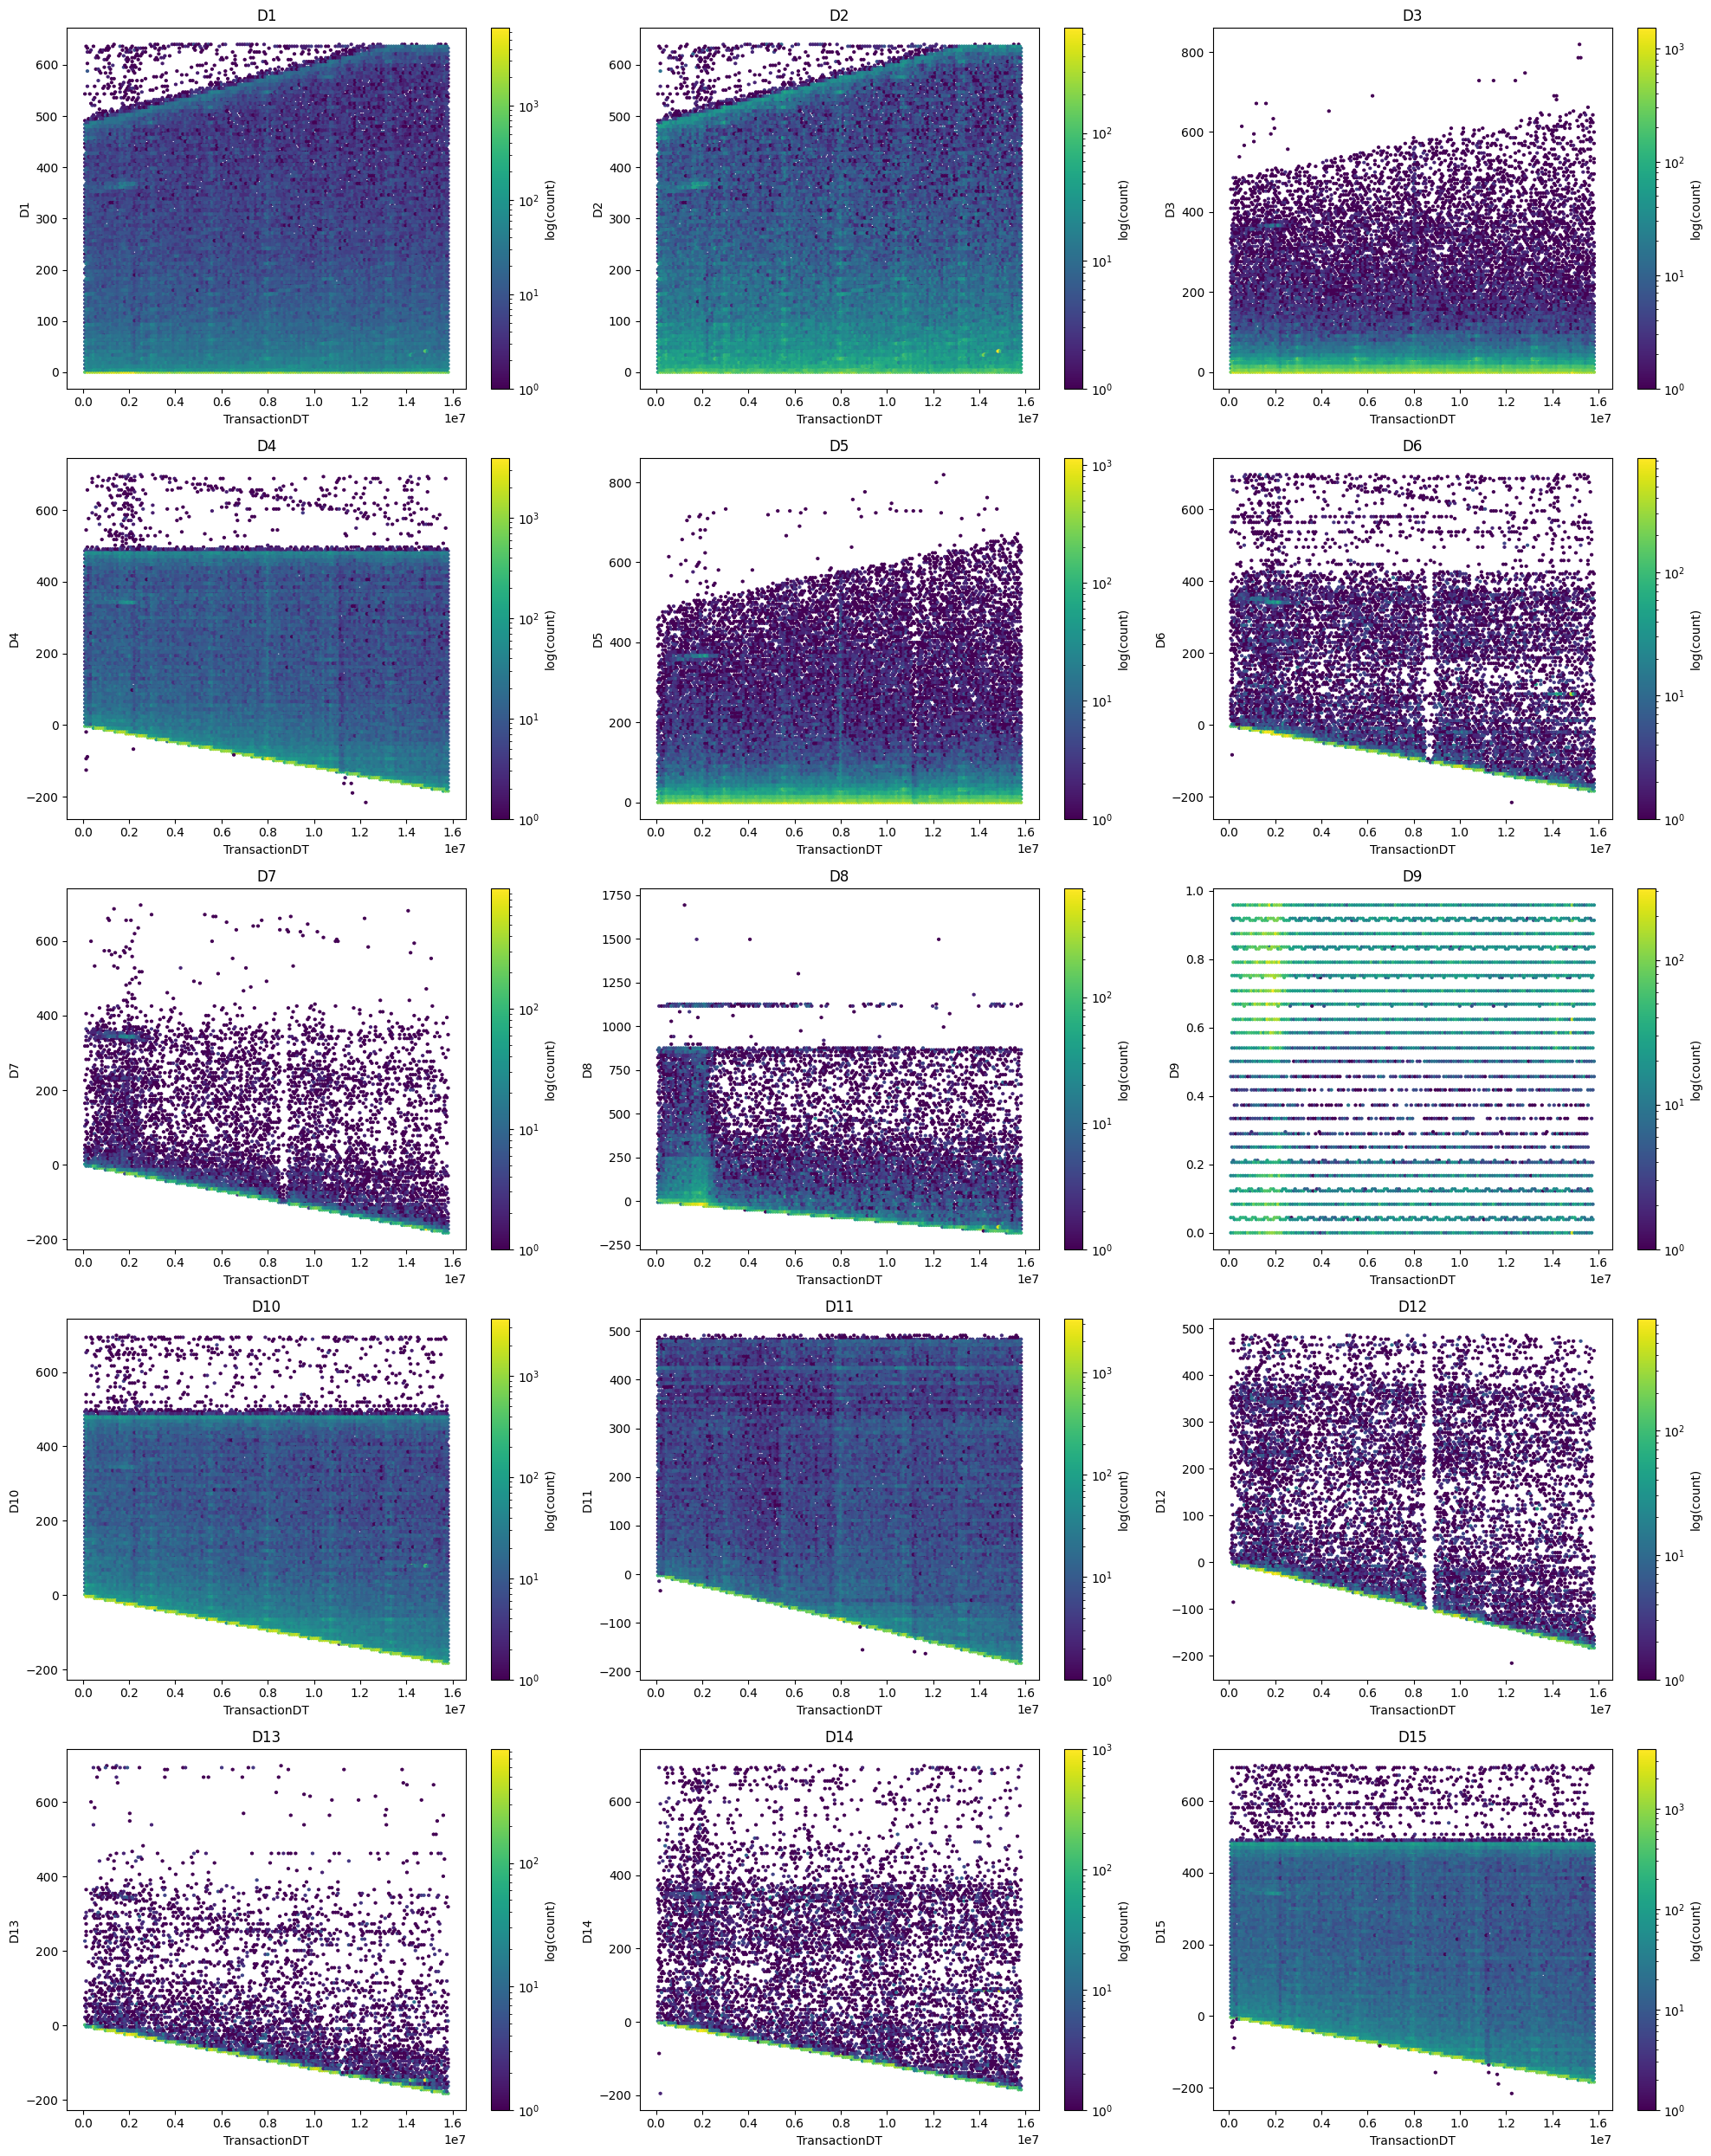

In [14]:
fig, axes = plt.subplots(5, 3, figsize=(20, 25))
axes = axes.flatten()

for i in range(1, 16):
    col = f'D{i}'
    subset = X_train[X_train[col].notna()]
    
    hb = axes[i-1].hexbin(
        subset['TransactionDT'],
        subset[col],
        gridsize=150,
        bins='log',
        cmap='viridis',
        mincnt=1
    )

    axes[i-1].set_title(col)
    axes[i-1].set_xlabel('TransactionDT')
    axes[i-1].set_ylabel(col)

    # Individual colorbar for each subplot
    fig.colorbar(hb, ax=axes[i-1], label='log(count)')

plt.tight_layout()
plt.show()


## Time to Convert str data to int

>#


In [15]:
for col in X_train.columns:
    if X_train[col].dtype.name=="category" or X_train[col].dtype.name=="object":
    
        combined=pd.concat([X_train[col],X_test[col]],axis=0)
        codes, _ = pd.factorize(combined, sort=True)

        dtype = np.int32 if codes.max() > np.iinfo(np.int16).max else np.int16

        X_train[col] = codes[:len(X_train)].astype(dtype)
        X_test[col] = codes[len(X_train):].astype(dtype)


    elif col not in ["TransactionDT","TransactionAmt"]:

        min_val=min(X_train[col].min(),
                    X_test[col].min())

        X_train[col] = X_train[col] - np.float32(min_val)
        X_test[col] = X_test[col] - np.float32(min_val)

        X_train[col] = X_train[col].fillna(-1)
        X_test[col] = X_test[col].fillna(-1)


    

## ENCODING FUNCTIONS

In [16]:
def add_feature_frames(train_df, test_df, train_feats, test_feats):
    if train_feats:
        train_df = pd.concat(
            [train_df, pd.DataFrame(train_feats, index=train_df.index)],
            axis=1
        )

    if test_feats:
        test_df = pd.concat(
            [test_df, pd.DataFrame(test_feats, index=test_df.index)],
            axis=1
        )

    return train_df.copy(), test_df.copy()


def encode_fe(train_df, test_df, cols):
    train_feats = {}
    test_feats = {}

    for col in cols:
        combined = pd.concat([train_df[col], test_df[col]], axis=0)

        freq_map = combined.value_counts(
            dropna=True,
            normalize=True
        ).to_dict()

        new_col = f"{col}_FE"

        train_feats[new_col] = train_df[col].map(freq_map).astype("float32")
        test_feats[new_col] = test_df[col].map(freq_map).astype("float32")

        print(f"{new_col}, ", end="")

    return add_feature_frames(train_df, test_df, train_feats, test_feats)


def encode_le(train_df, test_df, col, verbose=True):
    combined = pd.concat([train_df[col], test_df[col]], axis=0)

    codes, _ = pd.factorize(combined, sort=True)

    dtype = "int32" if codes.max() > 32000 else "int16"

    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df[col] = codes[:len(train_df)].astype(dtype)
    test_df[col] = codes[len(train_df):].astype(dtype)

    del combined, codes
    gc.collect()

    if verbose:
        print(f"{col}, ", end="")

    return train_df, test_df

def encode_cb(train_df, test_df, col1, col2):
    new_col = f"{col1}_{col2}"

    train_feats = {
        new_col: train_df[col1].astype("string") + "_" + train_df[col2].astype("string")
    }

    test_feats = {
        new_col: test_df[col1].astype("string") + "_" + test_df[col2].astype("string")
    }

    train_df, test_df = add_feature_frames(
        train_df,
        test_df,
        train_feats,
        test_feats
    )

    train_df, test_df = encode_le(
        train_df,
        test_df,
        new_col,
        verbose=False
    )

    print(f"{new_col}, ", end="")

    return train_df, test_df

def encode_ag(
    train_df,
    test_df,
    main_columns,
    uids,
    aggregations=("mean",),
    fillna=True,
    usena=False
):
    train_feats = {}
    test_feats = {}

    for main_col in main_columns:
        for uid in uids:
            combined = pd.concat(
                [
                    train_df[[uid, main_col]],
                    test_df[[uid, main_col]]
                ],
                axis=0
            ).copy()

            if usena:
                combined[main_col] = combined[main_col].replace(-1, np.nan)

            for agg in aggregations:
                new_col = f"{main_col}_{uid}_{agg}"

                agg_map = combined.groupby(uid, dropna=False)[main_col].agg(agg)

                train_values = train_df[uid].map(agg_map).astype("float32")
                test_values = test_df[uid].map(agg_map).astype("float32")

                if fillna:
                    train_values = train_values.fillna(-1)
                    test_values = test_values.fillna(-1)

                train_feats[new_col] = train_values
                test_feats[new_col] = test_values

                print(f"'{new_col}', ", end="")

    return add_feature_frames(train_df, test_df, train_feats, test_feats)

def encode_ag2(train_df, test_df, main_columns, uids):
    train_feats = {}
    test_feats = {}

    for main_col in main_columns:
        for uid in uids:
            new_col = f"{uid}_{main_col}_ct"

            combined = pd.concat(
                [
                    train_df[[uid, main_col]],
                    test_df[[uid, main_col]]
                ],
                axis=0
            )

            nunique_map = combined.groupby(uid, dropna=False)[main_col].nunique()

            train_feats[new_col] = train_df[uid].map(nunique_map).astype("float32")
            test_feats[new_col] = test_df[uid].map(nunique_map).astype("float32")

            print(f"{new_col}, ", end="")

    return add_feature_frames(train_df, test_df, train_feats, test_feats)

## Feature Engineering

In [17]:
X_train = X_train.copy()
X_test = X_test.copy()

In [18]:
%%time

# TRANSACTION AMT CENTS
train_feats = {
    "cents": (
        X_train["TransactionAmt"] - np.floor(X_train["TransactionAmt"])
    ).astype("float32")
}

test_feats = {
    "cents": (
        X_test["TransactionAmt"] - np.floor(X_test["TransactionAmt"])
    ).astype("float32")
}

X_train, X_test = add_feature_frames(X_train, X_test, train_feats, test_feats)

print("cents, ", end="")


# FE
X_train, X_test = encode_fe(
    X_train,
    X_test,
    ["addr1", "card1", "card2", "card3", "P_emaildomain"]
)


# CB
X_train, X_test = encode_cb(X_train, X_test, "card1", "addr1")
X_train, X_test = encode_cb(X_train, X_test, "card1_addr1", "P_emaildomain")


# FE again
X_train, X_test = encode_fe(
    X_train,
    X_test,
    ["card1_addr1", "card1_addr1_P_emaildomain"]
)


# AG
X_train, X_test = encode_ag(
    X_train,
    X_test,
    main_columns=["TransactionAmt", "D9", "D11"],
    uids=["card1", "card1_addr1", "card1_addr1_P_emaildomain"],
    aggregations=("mean", "std"),
    usena=True
)

cents, addr1_FE, card1_FE, card2_FE, card3_FE, P_emaildomain_FE, card1_addr1, card1_addr1_P_emaildomain, card1_addr1_FE, card1_addr1_P_emaildomain_FE, 'TransactionAmt_card1_mean', 'TransactionAmt_card1_std', 'TransactionAmt_card1_addr1_mean', 'TransactionAmt_card1_addr1_std', 'TransactionAmt_card1_addr1_P_emaildomain_mean', 'TransactionAmt_card1_addr1_P_emaildomain_std', 'D9_card1_mean', 'D9_card1_std', 'D9_card1_addr1_mean', 'D9_card1_addr1_std', 'D9_card1_addr1_P_emaildomain_mean', 'D9_card1_addr1_P_emaildomain_std', 'D11_card1_mean', 'D11_card1_std', 'D11_card1_addr1_mean', 'D11_card1_addr1_std', 'D11_card1_addr1_P_emaildomain_mean', 'D11_card1_addr1_P_emaildomain_std', CPU times: user 6.82 s, sys: 1.31 s, total: 8.13 s
Wall time: 8.14 s


# ChatGPT suggested
[Link to Chat from ChatGPT that suggested ](https://chatgpt.com/g/g-p-6a0600ce3e488191a0cbda31e3550f76-fraud-detection/c/6a37baeb-4868-83e8-a9b1-f58fb95fba74)

# Feature Selection - Time Consistency


In [19]:
cols = list( X_train.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)
    
# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

NOW USING THE FOLLOWING 96 FEATURES.


array(['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card5',
       'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain',
       'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9',
       'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5',
       'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'M7', 'M8',
       'M9', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06',
       'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_15', 'id_16',
       'id_17', 'id_18', 'id_19', 'id_20', 'id_28', 'id_29', 'id_31',
       'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo',
       'cents', 'addr1_FE', 'card1_FE', 'card2_FE', 'card3_FE',
       'P_emaildomain_FE', 'card1_addr1', 'card1_addr1_P_emaildomain',
       'card1_addr1_FE', 'card1_addr1_P_emaildomain_FE',
       'TransactionAmt_card1_mean', 'TransactionAmt_card1_std',
       'TransactionAmt_card1_addr1_mean',
       'TransactionAmt_card1_addr1_std',
       'TransactionAmt_car

In [20]:
# CHRIS - TRAIN 75% PREDICT 25%
idxT = X_train.index[:3*len(X_train)//4]
idxV = X_train.index[3*len(X_train)//4:]

In [21]:
print(type(Y_train))
print(type(idxT))

<class 'pandas.core.series.Series'>
<class 'pandas.core.indexes.base.Index'>


# ChatGPT Suggestion
[Link to the chat](https://chatgpt.com/g/g-p-6a0600ce3e488191a0cbda31e3550f76/c/6a37baeb-4868-83e8-a9b1-f58fb95fba74)

In [22]:
X_train = X_train.copy()
X_test = X_test.copy()

# ChatGPT solution
[One more more comprehensive chat](https://chatgpt.com/g/g-p-6a0600ce3e488191a0cbda31e3550f76-fraud-detection/c/6a367e4a-f784-83ee-af53-fb00b5edfd70)


In [23]:
def optimize(df):
    for col in df.columns:
        if df[col].dtype == "float64":
            df[col] = df[col].astype("float32")
        elif df[col].dtype == "int64":
            df[col] = df[col].astype("int32")
    return df

X_train = optimize(X_train)
X_test = optimize(X_test)

X_train = X_train.copy()
X_test = X_test.copy()

Y = Y_train.astype("int8")

In [24]:
print("XGBoost version:", xgb.__version__)


clf = xgb.XGBClassifier(
        n_estimators=2000,
        max_depth=12,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.4,
        missing=-1,
        eval_metric='auc',
        tree_method='hist',
        device='cuda',
        early_stopping_rounds=100
    )

h = clf.fit(
        X_train.loc[idxT, cols],
        Y_train[idxT],
        eval_set=[(X_train.loc[idxV, cols], Y_train[idxV])],
        verbose=50
    )

XGBoost version: 3.2.0
[0]	validation_0-auc:0.82485
[50]	validation_0-auc:0.91174
[100]	validation_0-auc:0.92023
[150]	validation_0-auc:0.92703
[200]	validation_0-auc:0.93020
[250]	validation_0-auc:0.93215
[300]	validation_0-auc:0.93327
[350]	validation_0-auc:0.93376
[400]	validation_0-auc:0.93411
[450]	validation_0-auc:0.93409
[500]	validation_0-auc:0.93403
[516]	validation_0-auc:0.93385


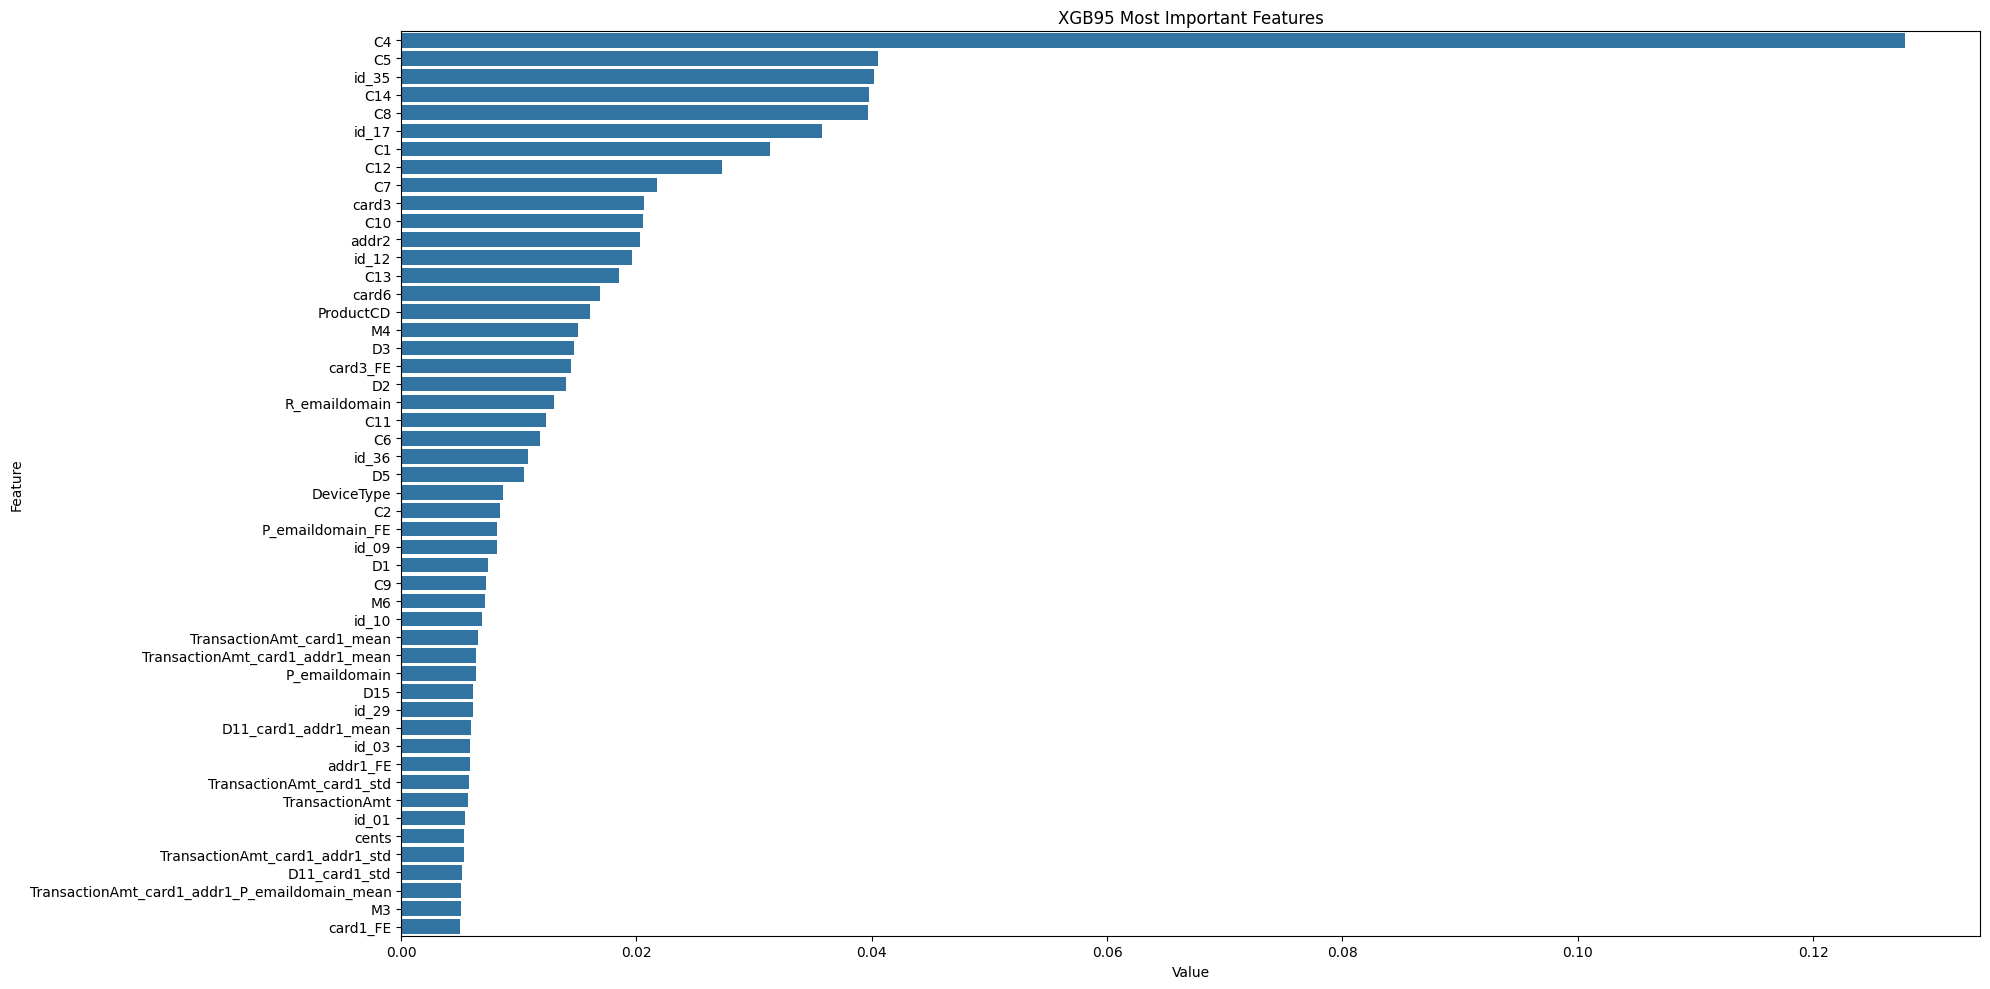

In [25]:
feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
plt.figure(figsize=(20, 10))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
plt.title('XGB95 Most Important Features')
plt.tight_layout()
plt.show()
del clf, h; x=gc.collect()

## Predict Test

In [26]:
import datetime
START_DATE = datetime.datetime.strptime('2017-11-30', '%Y-%m-%d')
X_train['DT_M'] = X_train['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_train['DT_M'] = (X_train['DT_M'].dt.year-2017)*12 + X_train['DT_M'].dt.month 

X_test['DT_M'] = X_test['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_test['DT_M'] = (X_test['DT_M'].dt.year-2017)*12 + X_test['DT_M'].dt.month 

## Tweaked by Calude
[Link](https://claude.ai/share/d8e08a63-1a02-40df-969b-2b2964dbd73a)

In [27]:
import cupy as cp


oof = np.zeros(len(X_train), dtype=np.float32)
preds = np.zeros(len(X_test), dtype=np.float32)

skf = GroupKFold(n_splits=6)

# convert once, on CPU (needed for sklearn's split + groups)
X = X_train[cols].to_numpy()
Y = Y_train.to_numpy()
X_test_np = X_test[cols].to_numpy()
groups = X_train["DT_M"].to_numpy()

# ✅ move to GPU once — this is the actual fix for the device-mismatch warning
X_gpu = cp.asarray(X)
X_test_gpu = cp.asarray(X_test_np)

for fold, (idx_train, idx_valid) in enumerate(
    skf.split(X, Y, groups=groups)
):

    month = X_train.iloc[idx_valid]["DT_M"].iat[0]

    print(f"Fold {fold} withholding month {month}")
    print(f"rows train = {len(idx_train)} rows holdout = {len(idx_valid)}")

    # cupy fancy-indexing accepts numpy int arrays directly
    idx_train_gpu = cp.asarray(idx_train)
    idx_valid_gpu = cp.asarray(idx_valid)

    clf = xgb.XGBClassifier(
        n_estimators=5000,
        max_depth=12,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.4,
        missing=-1,
        eval_metric="auc",
        tree_method="hist",
        device="cuda",
        early_stopping_rounds=200,
    )

    clf.fit(
        X_gpu[idx_train_gpu],
        Y[idx_train],
        eval_set=[(X_gpu[idx_valid_gpu], Y[idx_valid])],
        verbose=100,
    )

    # ✅ all-GPU predict — no device mismatch, no DMatrix fallback
    oof[idx_valid] = cp.asnumpy(clf.predict_proba(X_gpu[idx_valid_gpu])[:, 1])
    preds += cp.asnumpy(clf.predict_proba(X_test_gpu)[:, 1]) / skf.n_splits
    
    del clf
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()

print("#" * 20)
print("XGB95 OOF CV =", roc_auc_score(Y, oof))

Fold 0 withholding month 12
rows train = 453219 rows holdout = 137321
[0]	validation_0-auc:0.78947
[100]	validation_0-auc:0.88725
[200]	validation_0-auc:0.89684
[300]	validation_0-auc:0.89920
[400]	validation_0-auc:0.89949
[500]	validation_0-auc:0.89960
[572]	validation_0-auc:0.89911
Fold 1 withholding month 15
rows train = 488908 rows holdout = 101632
[0]	validation_0-auc:0.84879
[100]	validation_0-auc:0.93003
[200]	validation_0-auc:0.94090
[300]	validation_0-auc:0.94492
[400]	validation_0-auc:0.94552
[500]	validation_0-auc:0.94591
[600]	validation_0-auc:0.94595
[700]	validation_0-auc:0.94617
[800]	validation_0-auc:0.94582
[900]	validation_0-auc:0.94555
[918]	validation_0-auc:0.94557
Fold 2 withholding month 13
rows train = 497955 rows holdout = 92585
[0]	validation_0-auc:0.83050
[100]	validation_0-auc:0.92470
[200]	validation_0-auc:0.93274
[300]	validation_0-auc:0.93652
[400]	validation_0-auc:0.93750
[500]	validation_0-auc:0.93763
[600]	validation_0-auc:0.93736
[700]	validation_0-auc

In [28]:

MODEL_DIR = "/kaggle/working/models/xgb95"
os.makedirs(MODEL_DIR, exist_ok=True)

# Convert once
X = X_train[cols].to_numpy(dtype=np.float32)
Y = Y_train.to_numpy()
groups = X_train["DT_M"].to_numpy()

# Move train data to GPU
X_gpu = cp.asarray(X)

# Final model trained on ALL labeled data
final_model = xgb.XGBClassifier(
    n_estimators=5000,          # or use avg/best_iteration from CV
    max_depth=12,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.4,
    missing=-1,
    eval_metric="auc",
    tree_method="hist",
    device="cuda",
)

final_model.fit(
    X_gpu,
    Y,
    verbose=100,
)

# =========================
# Save native XGBoost UBJ
# =========================
ubj_path = os.path.join(MODEL_DIR, "xgb95_final.ubj")
final_model.save_model(ubj_path)

# Save feature order
features_path = os.path.join(MODEL_DIR, "xgb95_final_features.pkl")
joblib.dump(cols, features_path)

# =========================
# Save ONNX
# =========================

""" 

ONNX needs missing as nan and wont accept if its interpreted from -1
as we had replaced nans with-1 and in xgb tree also we mentioned in a param the same:
missing=-1


onnx_path = os.path.join(MODEL_DIR, "xgb95_final.onnx")

initial_type = [
    ("float_input", FloatTensorType([None, len(cols)]))
]

onnx_model = onnxmltools.convert_xgboost(
    final_model,
    initial_types=initial_type
)

with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

"""

print("Saved:")
print("UBJ     :", ubj_path)
#print("ONNX    :", onnx_path)
print("FEATURES:", features_path)

gc.collect()
cp.get_default_memory_pool().free_all_blocks()

Saved:
UBJ     : /kaggle/working/models/xgb95/xgb95_final.ubj
FEATURES: /kaggle/working/models/xgb95/xgb95_final_features.pkl
